# EDA for existing data

## Base imports

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")
%matplotlib inline

## Read Data files and analyse data types

In [145]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
store_path = DATA_DIR / "store.csv"

In [146]:
train = pd.read_csv(train_path, low_memory=False)
test = pd.read_csv(test_path, low_memory=False)
store = pd.read_csv(store_path, low_memory=False)

print("train shape:", train.shape)
print("test shape:", test.shape)
print("store shape:", store.shape)

train shape: (1017209, 9)
test shape: (41088, 8)
store shape: (1115, 10)


### Look at train data

In [147]:
train.dtypes

Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [148]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


### Look at test data

In [149]:
test.dtypes

Id                 int64
Store              int64
DayOfWeek          int64
Date              object
Open             float64
Promo              int64
StateHoliday      object
SchoolHoliday      int64
dtype: object

In [150]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


### Look at store data

In [151]:
store.dtypes

Store                          int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [152]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [153]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Convert and unify data values

In [154]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

In [155]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [156]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id             41088 non-null  int64         
 1   Store          41088 non-null  int64         
 2   DayOfWeek      41088 non-null  int64         
 3   Date           41088 non-null  datetime64[ns]
 4   Open           41077 non-null  float64       
 5   Promo          41088 non-null  int64         
 6   StateHoliday   41088 non-null  object        
 7   SchoolHoliday  41088 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 2.5+ MB


## Collect data statistics and useful values

### Check date ranges

In [157]:
print("Date range in train:", train["Date"].min(), "-", train["Date"].max())
print("Date range in test:", test["Date"].min(), "-", test["Date"].max())

Date range in train: 2013-01-01 00:00:00 - 2015-07-31 00:00:00
Date range in test: 2015-08-01 00:00:00 - 2015-09-17 00:00:00


### Basic statistics for Sales and Customers

In [158]:
train[["Sales", "Customers"]].describe()

,Sales,Customers
count,1.017209e+06,1.017209e+06
mean,5.773819e+03,6.331459e+02
std,3.849926e+03,4.644117e+02
min,0.000000e+00,0.000000e+00
25%,3.727000e+03,4.050000e+02
50%,5.744000e+03,6.090000e+02
75%,7.856000e+03,8.370000e+02
max,4.155100e+04,7.388000e+03


### Total open vs closed days

In [159]:
closed = train[train["Open"] == 0]
open_days = train[train["Open"] == 1]

print("Total rows:", len(train))
print("Closed days in train:", len(closed))
print("Open days in train:", len(open_days))

Total rows: 1017209
Closed days in train: 172817
Open days in train: 844392


### Non-zero sales when store is closed (data quality check)

In [160]:
nonzero_when_closed = closed[closed["Sales"] > 0]
print("Non-zero sales when closed:", len(nonzero_when_closed))
if len(nonzero_when_closed) > 0:
    print(nonzero_when_closed.head())

Non-zero sales when closed: 0


### Distribution of sales for train data

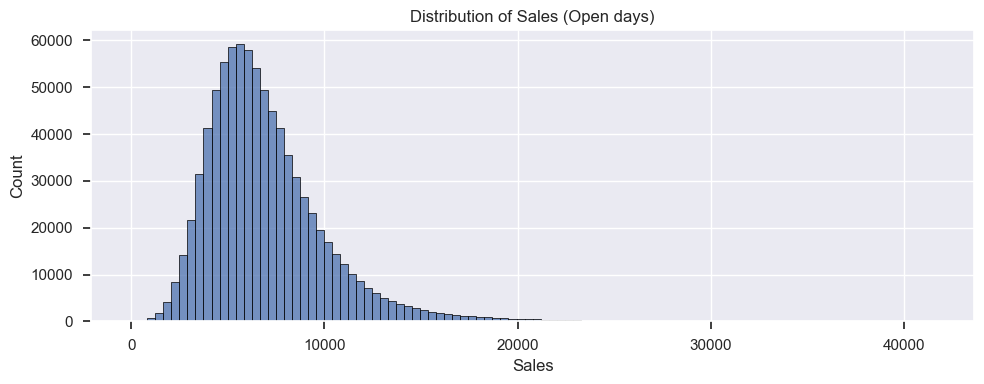

In [161]:
plt.figure(figsize=(10, 4))
sns.histplot(open_days["Sales"], bins=100, kde=False)
plt.title("Distribution of Sales (Open days)")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Average daily sales over time for train data

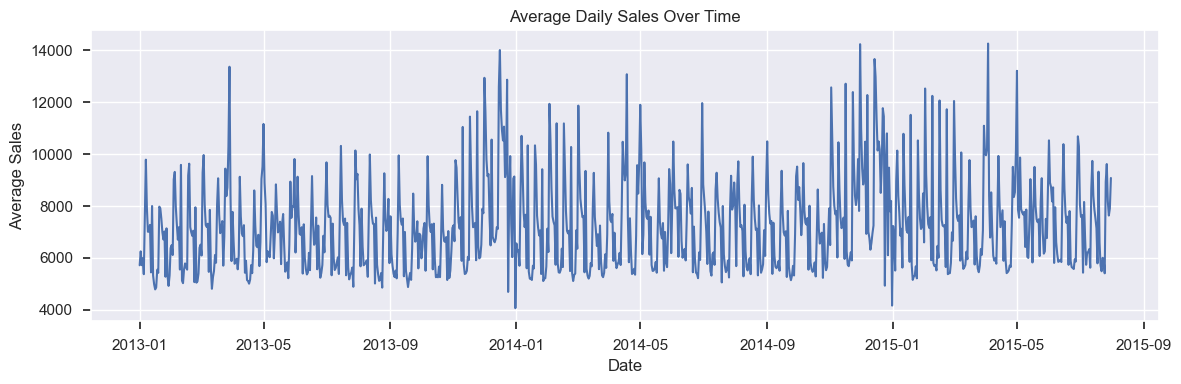

In [162]:
daily_sales = open_days.groupby("Date")["Sales"].mean()

plt.figure(figsize=(12, 4))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Average Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Sales by day of week

/var/folders/dt/5_4fw0_s3v91yn54hxtnfn9w0000gp/T/ipykernel_95064/2910710446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_days["DayOfWeek"] = open_days["Date"].dt.day_name()


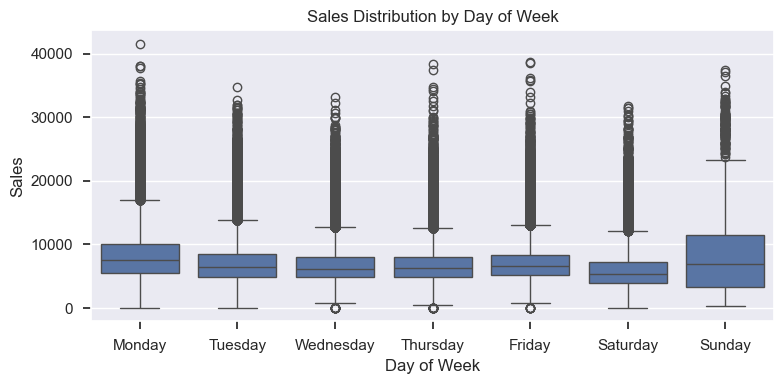

In [163]:
open_days["DayOfWeek"] = open_days["Date"].dt.day_name()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 4))
sns.boxplot(data=open_days, x="DayOfWeek", y="Sales", order=order)
plt.title("Sales Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Average Sales by Promo

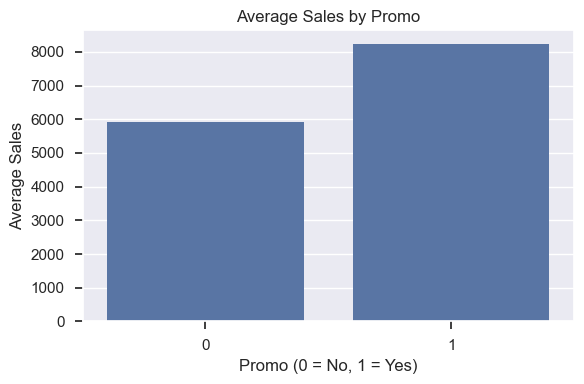

In [164]:
promo_sales = open_days.groupby("Promo")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=promo_sales.index.astype(str), y=promo_sales.values)
plt.title("Average Sales by Promo")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Average Sales by State Holidays

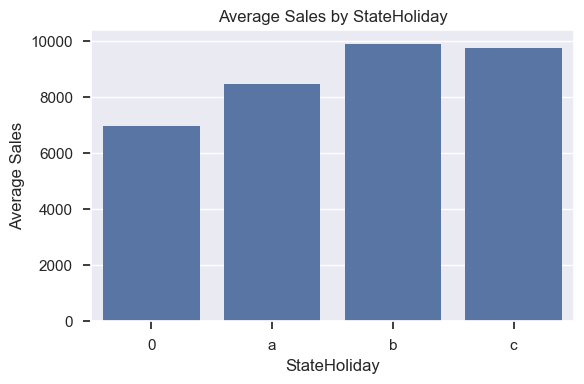

In [165]:
holiday_sales = open_days.groupby("StateHoliday")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=holiday_sales.index.astype(str), y=holiday_sales.values)
plt.title("Average Sales by StateHoliday")
plt.xlabel("StateHoliday")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Average Sales By School Holiday

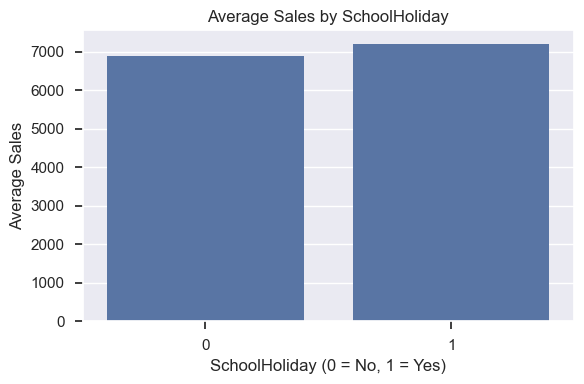

In [166]:
school_sales = open_days.groupby("SchoolHoliday")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=school_sales.index.astype(str), y=school_sales.values)
plt.title("Average Sales by SchoolHoliday")
plt.xlabel("SchoolHoliday (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## Merge Train with Store Data

In [167]:
train_store = train.merge(store, on="Store", how="left")

print("train_store shape:", train_store.shape)

train_store shape: (1017209, 18)


In [168]:
train_store.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Missing values analysis

In [169]:
def missing_summary(df, name="Dataframe"):
    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        "Missing count": missing,
        "Missing %": missing_pct
    })
    summary = summary[summary["Missing count"] > 0].sort_values("Missing count", ascending=False)
    return summary

missing_summary(train, "train")

,Missing count,Missing %


In [170]:
missing_summary(test, "test")

,Missing count,Missing %
Open,11,0.03


In [171]:
missing_summary(store, "store")

,Missing count,Missing %
Promo2SinceWeek,544,48.79
Promo2SinceYear,544,48.79
PromoInterval,544,48.79
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
CompetitionDistance,3,0.27


In [172]:
missing_summary(train_store, "train_store")

,Missing count,Missing %
Promo2SinceWeek,508031,49.94
Promo2SinceYear,508031,49.94
PromoInterval,508031,49.94
CompetitionOpenSinceMonth,323348,31.79
CompetitionOpenSinceYear,323348,31.79
CompetitionDistance,2642,0.26


### Fill the missing values

In [173]:
df = train_store.copy()

# Promo2-related columns: ~50% missing
# We will create:
#   - is_Promo2_known: 1 if Promo2SinceWeek/Year are not NA, 0 otherwise
#   - months_since_Promo2: approximate months since Promo2 started
#   - keep Promo2 (0/1) as is

df["is_Promo2_known"] = (
    df["Promo2SinceWeek"].notna() & df["Promo2SinceYear"].notna()
).astype(int)

# Approximate months since Promo2 start:
# months = Promo2SinceYear * 12 + Promo2SinceWeek * (1 month ~ 4 weeks)
df["months_since_Promo2"] = np.nan
mask_promo2 = df["Promo2SinceYear"].notna()
df.loc[mask_promo2, "months_since_Promo2"] = (
    df.loc[mask_promo2, "Promo2SinceYear"] * 12
    + df.loc[mask_promo2, "Promo2SinceWeek"] * 0.25
)

# For missing values, set to 0 (meaning "no Promo2 info / not active")
df["months_since_Promo2"] = df["months_since_Promo2"].fillna(0)

# PromoInterval - we will mark it as categorical with "unknown" for missing.
df["PromoInterval"] = df["PromoInterval"].fillna("unknown")


In [174]:
# CompetitionOpenSinceMonth/Year: ~32% missing
# We will create:
#   - is_competition_open_known
#   - months_since_competition_open
df["is_competition_open_known"] = (
    df["CompetitionOpenSinceMonth"].notna() & df["CompetitionOpenSinceYear"].notna()
).astype(int)

df["months_since_competition_open"] = np.nan
mask_comp = df["CompetitionOpenSinceYear"].notna()
df.loc[mask_comp, "months_since_competition_open"] = (
    df.loc[mask_comp, "CompetitionOpenSinceYear"] * 12
    + df.loc[mask_comp, "CompetitionOpenSinceMonth"]
)

# For missing, set to 0 (no competitor info)
df["months_since_competition_open"] = df["months_since_competition_open"].fillna(0)

In [175]:
# CompetitionDistance: only 0.26% missing -> fill with median
median_comp_dist = df["CompetitionDistance"].median()
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(median_comp_dist)

In [176]:
# Drop original columns with many missing values
cols_to_drop = [
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
]

df = df.drop(columns=cols_to_drop)

In [177]:
# Final check
missing_summary(df, "train_store (after missing handling)")

,Missing count,Missing %


## Continue statistics analysis for merged and cleared dataframe

### Average Sales By StoreType

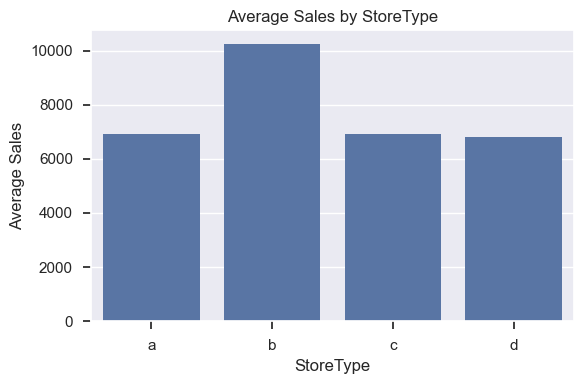

In [178]:
store_type_sales = df[df["Open"] == 1].groupby("StoreType")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=store_type_sales.index.astype(str), y=store_type_sales.values)
plt.title("Average Sales by StoreType")
plt.xlabel("StoreType")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Average Sales by Assortment

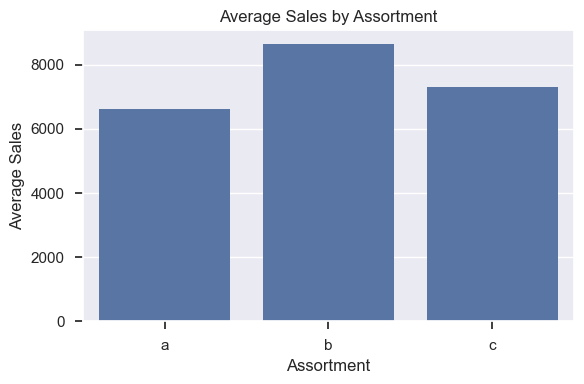

In [179]:
assort_sales = df[df["Open"] == 1].groupby("Assortment")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=assort_sales.index.astype(str), y=assort_sales.values)
plt.title("Average Sales by Assortment")
plt.xlabel("Assortment")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Sales By CompetitionDistance bins

/var/folders/dt/5_4fw0_s3v91yn54hxtnfn9w0000gp/T/ipykernel_95064/209030813.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comp_dist_sales = comp_dist.groupby("CompDistBin")["Sales"].mean()


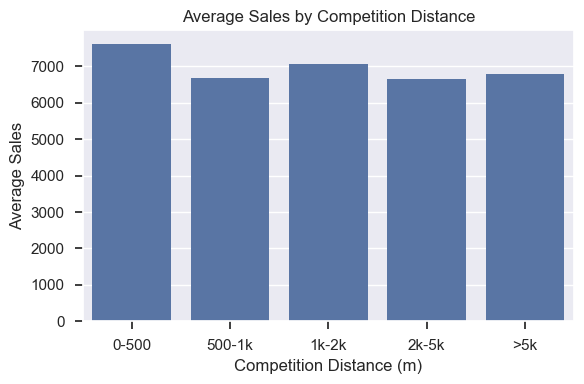

In [180]:
comp_dist = df[df["CompetitionDistance"].notna() & (df["Open"] == 1)].copy()

comp_dist["CompDistBin"] = pd.cut(
    comp_dist["CompetitionDistance"],
    bins=[0, 500, 1000, 2000, 5000, 100000],
    labels=["0-500", "500-1k", "1k-2k", "2k-5k", ">5k"],
)

comp_dist_sales = comp_dist.groupby("CompDistBin")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=comp_dist_sales.index.astype(str), y=comp_dist_sales.values)
plt.title("Average Sales by Competition Distance")
plt.xlabel("Competition Distance (m)")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

### Sales By Promo2

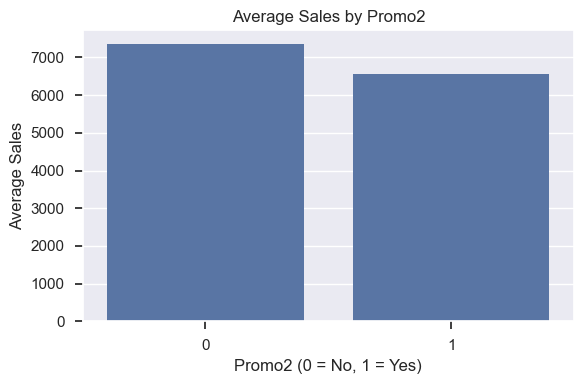

In [181]:
promo2_sales = df[df["Open"] == 1].groupby("Promo2")["Sales"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=promo2_sales.index.astype(str), y=promo2_sales.values)
plt.title("Average Sales by Promo2")
plt.xlabel("Promo2 (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

## Correlation analysis of features and target

### Prepare columns for correlation analysis

In [182]:
df_corr = df[df["Open"] == 1].copy()

num_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numeric columns after missing handling:", num_cols)

Numeric columns after missing handling: ['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'is_Promo2_known', 'months_since_Promo2', 'is_competition_open_known', 'months_since_competition_open']


### Correlation with Sales

In [183]:
target = "Sales"
num_corr = df_corr[num_cols].corr()

corr_with_sales = num_corr[target].drop(target).sort_values(ascending=False)

print("=== Correlation with Sales (after missing handling) ===")
print(corr_with_sales)

=== Correlation with Sales (after missing handling) ===
Customers                        0.823597
Promo                            0.368145
SchoolHoliday                    0.038617
Store                            0.007710
months_since_competition_open    0.005257
is_competition_open_known        0.005195
CompetitionDistance             -0.035852
Promo2                          -0.127596
is_Promo2_known                 -0.127596
months_since_Promo2             -0.127609
DayOfWeek                       -0.178736
Open                                  NaN
Name: Sales, dtype: float64


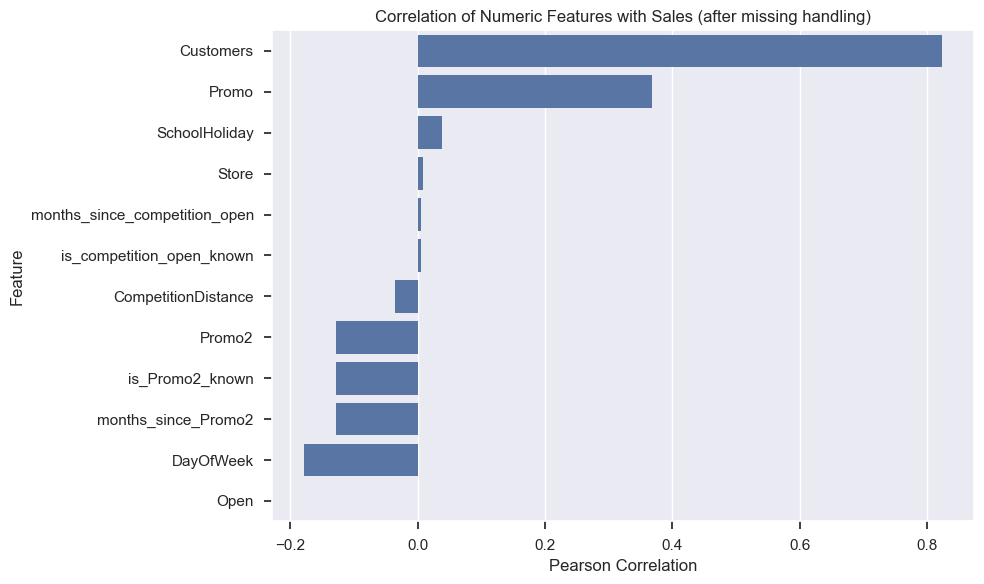

In [184]:
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_sales.values, y=corr_with_sales.index)
plt.title("Correlation of Numeric Features with Sales (after missing handling)")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

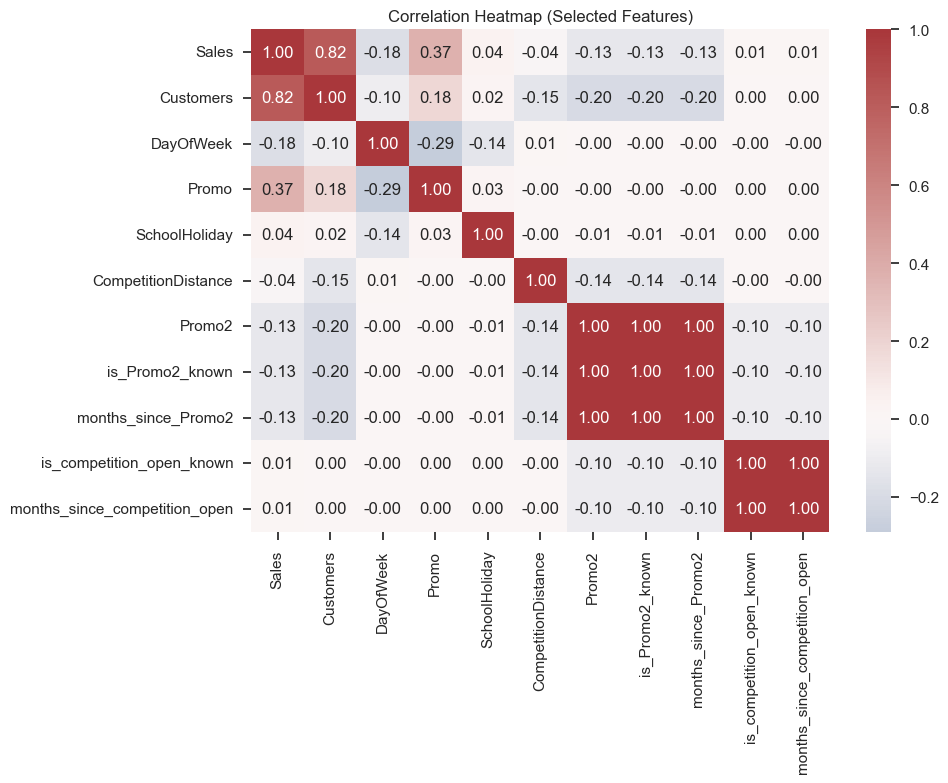

In [185]:
features_for_heatmap = [
    "Sales",
    "Customers",
    "DayOfWeek",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "Promo2",
    "is_Promo2_known",
    "months_since_Promo2",
    "is_competition_open_known",
    "months_since_competition_open",
]

features_for_heatmap = [f for f in features_for_heatmap if f in df_corr.columns]

df_heat = df_corr[features_for_heatmap]

plt.figure(figsize=(10, 8))
sns.heatmap(df_heat.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap (Selected Features)")
plt.tight_layout()
plt.show()

### Sales VS Customers Scatter Plot

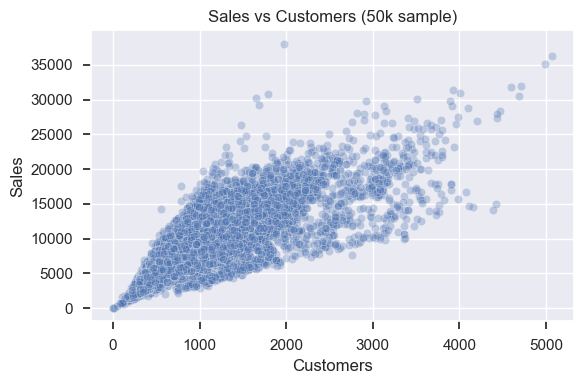

In [186]:
sample = open_days.sample(n=50000, random_state=42)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=sample["Customers"], y=sample["Sales"], alpha=0.3)
plt.title("Sales vs Customers (50k sample)")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Sales distribution by StoreType and Promo

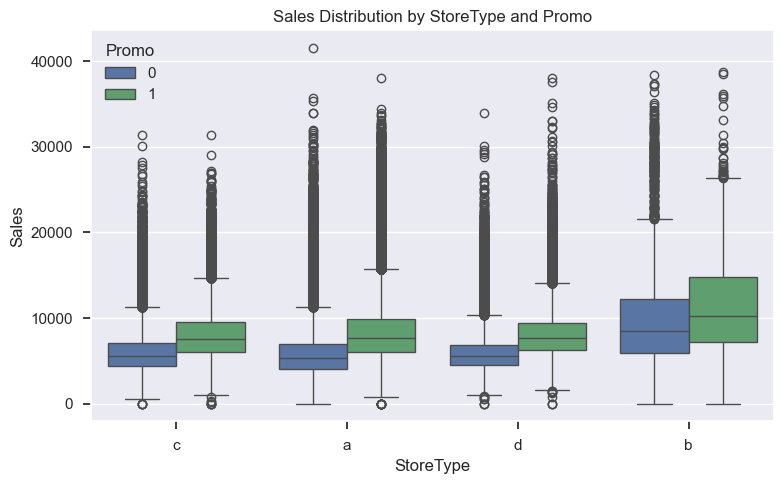

In [187]:
df_viz = df[df["Open"] == 1].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_viz, x="StoreType", y="Sales", hue="Promo")
plt.title("Sales Distribution by StoreType and Promo")
plt.xlabel("StoreType")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Sales distribution by Assortment and Promo2

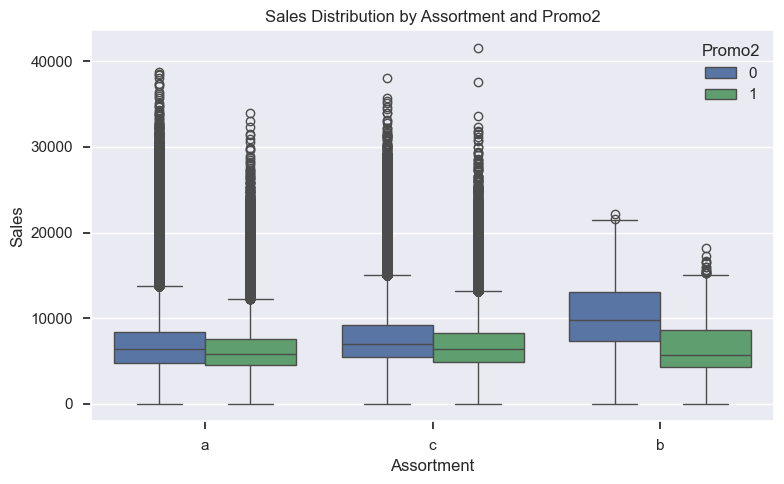

In [188]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_viz, x="Assortment", y="Sales", hue="Promo2")
plt.title("Sales Distribution by Assortment and Promo2")
plt.xlabel("Assortment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [189]:
# save final train data file
df.to_csv(DATA_DIR / "train_processed.csv")

## Finally transform test data according to the train

In [190]:
# Merge with store data
test_store = test.merge(store, on="Store", how="left")

In [191]:
# 1. Promo2-related columns: add is_Promo2_known and months_since_Promo2
test_store["is_Promo2_known"] = (
    test_store["Promo2SinceWeek"].notna() & test_store["Promo2SinceYear"].notna()
).astype(int)

test_store["months_since_Promo2"] = np.nan
mask_promo2 = test_store["Promo2SinceYear"].notna()
test_store.loc[mask_promo2, "months_since_Promo2"] = (
    test_store.loc[mask_promo2, "Promo2SinceYear"] * 12
    + test_store.loc[mask_promo2, "Promo2SinceWeek"] * 0.25
)
test_store["months_since_Promo2"] = test_store["months_since_Promo2"].fillna(0)

# 2. PromoInterval – fill "unknown"
test_store["PromoInterval"] = test_store["PromoInterval"].fillna("unknown")

# 3. CompetitionOpenSinceMonth/Year: add is_competition_open_known and months_since_competition_open
test_store["is_competition_open_known"] = (
    test_store["CompetitionOpenSinceMonth"].notna() & test_store["CompetitionOpenSinceYear"].notna()
).astype(int)

test_store["months_since_competition_open"] = np.nan
mask_comp = test_store["CompetitionOpenSinceYear"].notna()
test_store.loc[mask_comp, "months_since_competition_open"] = (
    test_store.loc[mask_comp, "CompetitionOpenSinceYear"] * 12
    + test_store.loc[mask_comp, "CompetitionOpenSinceMonth"]
)
test_store["months_since_competition_open"] = test_store["months_since_competition_open"].fillna(0)

# 4. CompetitionDistance – fill with median from train
test_store["CompetitionDistance"] = test_store["CompetitionDistance"].fillna(median_comp_dist)

# 5. Open – fill NaN with 1 as the most part of days are open
test_store["Open"] = test_store["Open"].fillna(1)

# 6. Delete initial columns
cols_to_drop = [
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
]
test_store = test_store.drop(columns=cols_to_drop)

In [192]:
# Check missing values
missing = test_store.isna().sum()
print("Пропуски после обработки:")
print(missing[missing > 0])

Пропуски после обработки:
Series([], dtype: int64)


In [193]:
# save final test data file
test_store.to_csv(DATA_DIR / "test_processed.csv", index=False)
print("Тестовые данные обработаны и сохранены в test_processed.csv")

Тестовые данные обработаны и сохранены в test_processed.csv


## EDA Summary

### Data overview

- The training set contains 1,017,209 rows for 1,115 stores.
- The test set contains 41,088 rows.
- The store table contains 1,115 rows, one per store.
- The training period spans from 2013-01-01 to 2015-07-31.
- The test period spans from 2015-08-01 to 2015-09-17.

### Data quality and missing values

- The `Open` column clearly separates closed and open days.
- There are 172,817 closed days and 844,392 open days in the training set.
- Non-zero sales when stores are closed are absent, which is a very good sign for data consistency.
- In the merged `train_store` dataframe, the following columns have substantial missing values:
  - `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval`: 508,031 missing values each, or 49.94%.
  - `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`: 323,348 missing values each, or 31.79%.
  - `CompetitionDistance`: 2,642 missing values, or 0.26%.

Instead of dropping these columns, I created new features:
- `is_Promo2_known`
- `months_since_Promo2`
- `is_competition_open_known`
- `months_since_competition_open`

I also:
- filled `CompetitionDistance` with the median,
- replaced missing `PromoInterval` with `"unknown"`,
- dropped the raw columns with many missing values.

This keeps the useful information from competition and promotion history while removing the direct impact of missing values.

### Sales distribution and time patterns

- Sales on open days are right-skewed: most values are moderate, with a long tail of large sales values.
- The time series of average daily sales shows visible variation over time and strong weekly patterns.
- Day of week clearly matters, which suggests that calendar features will be important in modeling.

### Effect of promotions and holidays

- Promo days have higher average sales than non-promo days.
- State holidays affect sales differently depending on category.
- School holidays also change the average sales level, although the effect appears weaker than for promo.

### Store characteristics

- Store type matters: different `StoreType` values show different average sales levels.
- Assortment also matters: stores with extended assortment tend to perform better.
- Competition distance appears relevant and should be kept as a feature.
- Promo2-related information is likely useful after feature engineering.

### Correlations and visual patterns

- `Customers` shows the strongest positive relationship with `Sales`, which is expected.
- Promo and date-related features also show meaningful relationships with sales.
- The correlation heatmap supports the idea that several features are informative, though they are not extremely collinear.
- This is good for tree-based models like LightGBM, which can combine these signals well.

### Overall conclusion

- The dataset is clean enough for modeling, but it needs careful handling of missing values and categorical variables.
- The strongest signals are likely to come from:
  - calendar effects,
  - promotions,
  - holidays,
  - store type and assortment,
  - competition-related features,
  - Promo2 history.
- The current preprocessing step makes the data much more usable for baseline modeling and later feature engineering.